In [10]:
import pandas as pd
df=pd.read_excel("D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx")
df.head()

,month,hh原始得分,hh中心化,snownlp原始得分,snownlp中心化,snownlp标题修正,训练snownlp原始得分,训练snownlp中心化,训练snownlp标题修正,svm原始得分,svm中心化,svm标题修正,nb原始得分,nb中心化,nb标题修正,宏观经济景气指数：一致指数,居民消费价格指数,PPI,社会消费品零售总额当期值(亿元),HS300
0,2019-03,0.117665,0.552479,0.619773,0.543285,0.595989,0.514771,0.502814,0.521837,0.212270,0.498225,0.326958,0.035112,0.502668,0.189307,99.45,102.28,100.4,43898.0,3872.34
1,2019-04,0.092671,0.515563,0.596502,0.515231,0.566479,0.516499,0.501374,0.523711,0.208627,0.545113,0.326481,0.027536,0.501769,0.197015,99.18,102.54,100.9,46291.3,3913.21
2,2019-05,0.083202,0.495003,0.618337,0.534403,0.581510,0.557234,0.550040,0.584430,0.258496,0.496930,0.315728,0.045842,0.511609,0.202797,98.80,102.70,100.6,41971.0,3629.79
3,2019-06,0.098951,0.528319,0.584822,0.501289,0.555155,0.525907,0.475394,0.543584,0.266726,0.625709,0.381746,0.052049,0.544299,0.217306,98.46,102.68,100.0,39667.6,3825.59
4,2019-07,0.110033,0.534599,0.627119,0.553329,0.585189,0.522839,0.480430,0.528639,0.319192,0.474423,0.312894,0.064565,0.514812,0.208227,98.29,102.78,99.7,38780.2,3835.36


In [11]:
from statsmodels.tsa.stattools import ccf
import pandas as pd
import pyecharts.options as opts
from pyecharts.charts import Line
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB


DF = df[(df['month'] >= '2021-07') & (df['month'] <= '2025-11')]
# 计算滞后范围
lags = range(-30, 31)

# 定义要分析的时间序列列名
columns = ['hh中心化', 'snownlp中心化', '训练snownlp中心化', 'svm中心化','nb中心化']

# 创建一个字典来保存每个系列的交叉相关值
ccf_results = {col: [ccf(DF['社会消费品零售总额当期值(亿元)'], DF[col], adjusted=True)[abs(lag)] if lag >= 0 else ccf(DF[col], DF['社会消费品零售总额当期值(亿元)'], adjusted=True)[abs(lag)] for lag in lags] for col in columns}

# 初始化 Pyecharts Line 图表
line = Line(init_opts=opts.InitOpts(width="1000px", height="500px"))

# 添加 X 轴数据（即滞后期）
x=list(lags)
line.add_xaxis(xaxis_data=x)

# 为每个时间序列添加 Y 轴数据，并设置是否初始显示
for col, ccf_values in ccf_results.items():
    y=ccf_values
    line.add_yaxis(
        series_name=col,
        y_axis=y,
        label_opts=opts.LabelOpts(is_show=False),  # 隐藏数据点标签
    )

# 设置全局配置项
line.set_global_opts(
    title_opts=opts.TitleOpts(title="Cross Correlation with cons",pos_left="center"),
    xaxis_opts=opts.AxisOpts(name="Lag",type_='value'),
    yaxis_opts=opts.AxisOpts(name="Cross Correlation"),
    
    tooltip_opts=opts.TooltipOpts(trigger="axis"),
    toolbox_opts=opts.ToolboxOpts(
        pos_left='57%',
        pos_top='5%',
        feature={
            "dataZoom": {"yAxisIndex": "none"},
            "restore": {},
            "saveAsImage": {},
            "brush": opts.ToolBoxFeatureBrushOpts(
                type_=["rect", "lineX", "keep", "clear"]
            ),
            "dataView":{},
            
        }
    ),
    brush_opts=opts.BrushOpts(),  # 启用刷选功能
    legend_opts=opts.LegendOpts(
        type_='scroll',
        orient='horizontal',
        pos_left='center',
        pos_top='bottom',
        selector=True,  # 启用选择器
        selector_position="end",  # 选择器位置在图例尾部
        selector_item_gap=10,  # 选择器按钮之间的间隔
        selector_button_gap=15,  # 选择器按钮与图例组件之间的间隔
    )
)

line.load_javascript()

In [12]:
# 渲染图表
line.render_notebook()

样本区间：2021-07 至 2025-11，共 53 期
---- 原序列 ----
svm中心化           ADF=-1.476, p=0.8373
PPI              ADF=-5.325, p=0.0001
---- 一阶差分 ----
D(svm中心化)        ADF=-2.187, p=0.4973
D(PPI)           ADF=-3.006, p=0.1304

残差 ADF = -3.859, p = 0.0001
=> 存在协整关系！


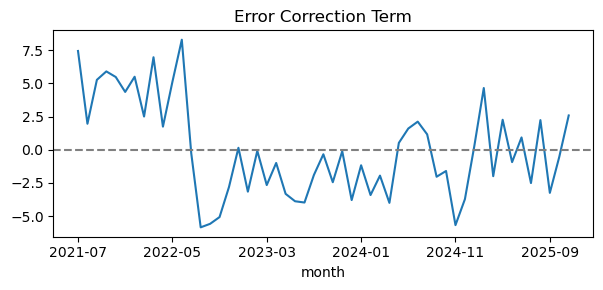

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# 1. 读数据 ----------------------------------------------------------
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet2', index_col='month')

y1 = df['svm中心化'].dropna()
y2 = df['PPI'].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]

print(f'样本区间：{common_idx[0]} 至 {common_idx[-1]}，共 {len(common_idx)} 期')

# 2. 单位根检验（仅 ADF） ---------------------------------------------
def adf_test(s, name):
    res = adfuller(s, regression='ct')
    print(f'{name:15s}  ADF={res[0]:.3f}, p={res[1]:.4f}')
    return res[1]

print('---- 原序列 ----')
p1 = adf_test(y1, 'svm中心化')
p2 = adf_test(y2, 'PPI')

print('---- 一阶差分 ----')
adf_test(y1.diff().dropna(), 'D(svm中心化)')
adf_test(y2.diff().dropna(), 'D(PPI)')

# 3. Engle-Granger 协整检验 ------------------------------------------
reg = OLS(y2, add_constant(y1)).fit()
resid = reg.resid

# 残差 ADF（无截距）
res_adf = adfuller(resid, regression='n')
print(f'\n残差 ADF = {res_adf[0]:.3f}, p = {res_adf[1]:.4f}')
if res_adf[0] < -2.89:          # 100 样本 5% 临界值约 -2.89
    print('=> 存在协整关系！')
else:
    print('=> 协整证据不足。')

# 4. 误差修正项 -------------------------------------------------------
ecm = resid.rename('ECM')
plt.figure(figsize=(6,3))
ecm.plot(title='Error Correction Term')
plt.axhline(0, color='grey', ls='--')
plt.tight_layout()
plt.show()

样本区间：2021-07 至 2025-11，共 53 期
---- 原序列 ----
snownlp中心化       ADF=-2.506, p=0.3250
社会消费品零售总额当期值(亿元)  ADF=-4.244, p=0.0038
---- 一阶差分 ----
D(snownlp)       ADF=-5.708, p=0.0000
D(社会消费品零售总额当期值(亿元))  ADF=-1.019, p=0.9416

残差 ADF = -3.558, p = 0.0004
=> 存在协整关系！


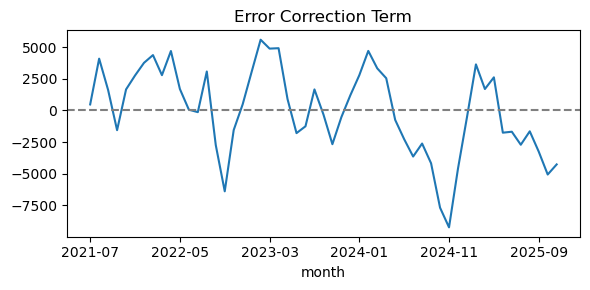

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# 1. 读数据 ----------------------------------------------------------
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet2', index_col='month')

y1 = df['snownlp中心化'].dropna()
y2 = df['社会消费品零售总额当期值(亿元)'].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]

print(f'样本区间：{common_idx[0]} 至 {common_idx[-1]}，共 {len(common_idx)} 期')

# 2. 单位根检验（仅 ADF） ---------------------------------------------
def adf_test(s, name):
    res = adfuller(s, regression='ct')
    print(f'{name:15s}  ADF={res[0]:.3f}, p={res[1]:.4f}')
    return res[1]

print('---- 原序列 ----')
p1 = adf_test(y1, 'snownlp中心化')
p2 = adf_test(y2, '社会消费品零售总额当期值(亿元)')

print('---- 一阶差分 ----')
adf_test(y1.diff().dropna(), 'D(snownlp)')
adf_test(y2.diff().dropna(), 'D(社会消费品零售总额当期值(亿元))')

# 3. Engle-Granger 协整检验 ------------------------------------------
reg = OLS(y2, add_constant(y1)).fit()
resid = reg.resid

# 残差 ADF（无截距）
res_adf = adfuller(resid, regression='n')
print(f'\n残差 ADF = {res_adf[0]:.3f}, p = {res_adf[1]:.4f}')
if res_adf[0] < -2.89:          # 100 样本 5% 临界值约 -2.89
    print('=> 存在协整关系！')
else:
    print('=> 协整证据不足。')

# 4. 误差修正项 -------------------------------------------------------
ecm = resid.rename('ECM')
plt.figure(figsize=(6,3))
ecm.plot(title='Error Correction Term')
plt.axhline(0, color='grey', ls='--')
plt.tight_layout()
plt.show()

样本区间：2021-07 至 2025-11，共 53 期
---- 原序列 ----
snownlp中心化       ADF=-2.506, p=0.3250
PPI              ADF=-5.325, p=0.0001
---- 一阶差分 ----
D(snownlp)       ADF=-5.708, p=0.0000
D(PPI)           ADF=-3.006, p=0.1304

残差 ADF = -2.006, p = 0.0429
=> 协整证据不足。


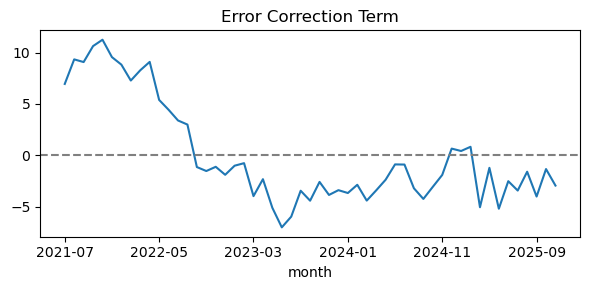

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# 1. 读数据 ----------------------------------------------------------
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet2', index_col='month')

y1 = df['snownlp中心化'].dropna()
y2 = df['PPI'].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]

print(f'样本区间：{common_idx[0]} 至 {common_idx[-1]}，共 {len(common_idx)} 期')

# 2. 单位根检验（仅 ADF） ---------------------------------------------
def adf_test(s, name):
    res = adfuller(s, regression='ct')
    print(f'{name:15s}  ADF={res[0]:.3f}, p={res[1]:.4f}')
    return res[1]

print('---- 原序列 ----')
p1 = adf_test(y1, 'snownlp中心化')
p2 = adf_test(y2, 'PPI')

print('---- 一阶差分 ----')
adf_test(y1.diff().dropna(), 'D(snownlp)')
adf_test(y2.diff().dropna(), 'D(PPI)')

# 3. Engle-Granger 协整检验 ------------------------------------------
reg = OLS(y2, add_constant(y1)).fit()
resid = reg.resid

# 残差 ADF（无截距）
res_adf = adfuller(resid, regression='n')
print(f'\n残差 ADF = {res_adf[0]:.3f}, p = {res_adf[1]:.4f}')
if res_adf[0] < -2.89:          # 100 样本 5% 临界值约 -2.89
    print('=> 存在协整关系！')
else:
    print('=> 协整证据不足。')

# 4. 误差修正项 -------------------------------------------------------
ecm = resid.rename('ECM')
plt.figure(figsize=(6,3))
ecm.plot(title='Error Correction Term')
plt.axhline(0, color='grey', ls='--')
plt.tight_layout()
plt.show()